In [70]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import simpson


class NanException(Exception):
    pass

T0 = 8000
Tw = 1800
p = 2
R = 0.35
Imax = 1000
Itmax = 80e-6
tmax = 2000e-6
c = 3 * 1e10
EPS = 1e-6
zmax = 1
z0 = 0
t0 = 0
variant = 1
tau_target = 1e-6


T_vals = [2000, 3000, 4000, 5000, 6000, 7000, 8000, 9000, 10000, 11000, 12000]
Sigma_vals = [0.309e-3, 0.309e-2, 0.309e-1, 0.270, 0.205e+1, 0.606e+1, 0.120e+2, 0.199e+2, 0.296e+2, 0.411e+2, 0.541e+2]
Lambda_vals = [0.381e-3, 0.381e-3, 0.381e-3, 0.448e-3, 0.577e-3, 0.733e-3, 0.131e-2, 0.218e-2, 0.358e-2, 0.562e-2,
               0.832e-2]
cT_vals = [1.90e-3, 1.90e-3, 0.95e-3, 0.75e-3, 0.64e-3, 0.61e-3, 0.66e-3, 0.66e-3, 1.15e-3, 1.79e-3, 2.02e-3]
K1_vals = [8.200E-03, 2.768E-02, 6.560E-02, 1.281E-01, 2.214E-01, 3.516E-01, 5.248E-01, 7.472E-01, 1.025E+00]
K2_vals = [1.6, 5.4, 1.280E+01, 2.500E+01, 4.320E+01, 6.860E+01, 1.024E+02, 1.458E+02, 2.000E+02]


def calc_I(t):
    return (Imax / Itmax) * t * np.exp(-(t / Itmax - 1))

def manual_interp(T, T_grid, V_grid):
    T_arr = np.atleast_1d(T)
    result = np.empty_like(T_arr, dtype=float)
    
    for idx, t in enumerate(T_arr):
        if t <= T_grid[0]:
            result[idx] = V_grid[0]
        elif t >= T_grid[-1]:
            result[idx] = V_grid[-1]
        else:
            for j in range(1, len(T_grid)):
                if T_grid[j-1] <= t <= T_grid[j]:
                    t0, t1 = T_grid[j-1], T_grid[j]
                    v0, v1 = V_grid[j-1], V_grid[j]
                    result[idx] = v0 + (v1 - v0) * (t - t0) / (t1 - t0)
                    break
        
    return result.item() if np.isscalar(T) else result
                    
def calc_sigma(T):
    return manual_interp(T, T_vals, Sigma_vals)

def calc_lambda(T):
    return manual_interp(T, T_vals, Lambda_vals)

def calc_cT(T):
    return manual_interp(T, T_vals, cT_vals)

def calc_k(T):
    grid = T_vals[:9]
    vals = K1_vals if variant == 1 else K2_vals
    return manual_interp(T, grid, vals)


def calc_T(z):
    return (Tw - T0) * z ** p + T0


# def calc_planca(T):
#     return 3.084e-4 / (np.exp(4.799 * 1e4 / T) - 1)

def calc_planca(T):
    x = 4.799e4 / T
    x = np.clip(x, None, 700)             
    return 3.084e-4 / (np.exp(x) - 1)


def calc_E(z, T, t):
    y = calc_sigma(T) * z
    n = len(z)
    if n == 1:
        integral = 0.0
    elif n == 2:
        h = z[1] - z[0]
        integral = h * (y[0] + y[1]) / 2
    else:
        h = z[1] - z[0]
        if n % 2 == 1:
            integral = h/3 * (
                y[0] + y[-1]
                + 4 * y[1:-1:2].sum()
                + 2 * y[2:-1:2].sum()
            )
        else:
            m1 = n - 1
            integral = h/3 * (
                y[0] + y[m1-1]
                + 4 * y[1:m1-1:2].sum()
                + 2 * y[2:m1-1:2].sum()
            )
            integral += h * (y[m1-1] + y[m1]) / 2

    return calc_I(t) / (2 * np.pi * R**2 * integral)


def calc_q(u, T, zindex):
    return c * calc_k(T[zindex]) * (calc_planca(T[zindex]) - u[zindex])


def solve_u(n, T):
    z = np.linspace(z0, zmax, n)
    h = np.diff(z)[0]

    a = np.zeros(n) 
    b = np.zeros(n)
    c = np.zeros(n)
    d = np.zeros(n)

    b[0] = 1
    c[0] = -1
    d[0] = 0

    for i in range(1, n - 1):
        k_prev = calc_k(T[i - 1])
        k_curr = calc_k(T[i])
        k_next = calc_k(T[i + 1])

        kappa_prev = 2 / (k_prev + k_curr)
        kappa_next = 2 / (k_curr + k_next)

        a[i] = -(z[i] - h / 2) * kappa_prev / R ** 2 / h
        c[i] = -(z[i] + h / 2) * kappa_next / R ** 2 / h
        b[i] = -a[i] - c[i] - 3 * calc_k(T[i]) * z[i] * h
        d[i] = -3 * calc_k(T[i]) * z[i] * h * calc_planca(T[i])

    k_prev = calc_k(T[-2])
    k_curr = calc_k(T[-1])
    kappa = 2 / (k_prev + k_curr)

    a[-1] = -kappa / R ** 2 / h * (2 - h)
    b[-1] = 3 * 0.39 / R - a[-1]
    d[-1] = 0

    # u = np.zeros(n)
    # for i in range(1, n):
    #     m = a[i] / b[i - 1]
    #     b[i] = b[i] - m * c[i - 1]
    #     d[i] = d[i] - m * d[i - 1]
    # 
    # u[-1] = d[-1] / b[-1]
    # for i in range(n - 2, -1, -1):
    #     u[i] = (d[i] - c[i] * u[i + 1]) / b[i]
    
    P = np.zeros(n)
    Q = np.zeros(n)
    
    P[-1] = a[-1] / b[-1]
    Q[-1] = d[-1] / b[-1]
    
    for i in range(n-2, -1, -1):
        denom = b[i] - c[i] * P[i+1]
        P[i]  = a[i] / denom
        Q[i]  = (d[i] - c[i] * Q[i+1]) / denom
    
    u = np.zeros(n)
    u[0] = Q[0]
    for i in range(1, n):
        u[i] = P[i] * u[i-1] + Q[i]

    return u


def Iteration(iter_T, prev_T, z, u, tau, t):
    n = len(z)
    h = np.diff(z)[0]

    a = np.zeros(n)
    b = np.zeros(n)
    c = np.zeros(n)
    d = np.zeros(n)

    b[0] = 1
    c[0] = -1
    d[0] = 0

    E = calc_E(z, iter_T, t)

    for i in range(1, n - 1):
        lambda_prev = calc_lambda(iter_T[i - 1])
        lambda_curr = calc_lambda(iter_T[i])
        lambda_next = calc_lambda(iter_T[i + 1])

        kappa_prev = 2 * lambda_prev * lambda_curr / (lambda_prev + lambda_curr)
        kappa_next = 2 * lambda_curr * lambda_next / (lambda_curr + lambda_next)

        A = tau / R ** 2 * (z[i] - h / 2) * kappa_prev / h
        C = tau / R ** 2 * (z[i] + h / 2) * kappa_next / h
        B = A + C + z[i] * h * calc_cT(iter_T[i])
        a[i] = -A
        b[i] = B
        c[i] = -C
        d[i] = z[i] * calc_cT(iter_T[i]) * prev_T[i] * h + tau * h * z[i] * (
                calc_sigma(iter_T[i]) * E ** 2 - calc_q(u, iter_T, i))

    a[-1] = 0
    b[-1] = 1
    d[-1] = Tw

    new_T = np.zeros(n)
    for i in range(1, n):
        m = a[i] / b[i - 1]
        b[i] = b[i] - m * c[i - 1]
        d[i] = d[i] - m * d[i - 1]

    new_T[-1] = d[-1] / b[-1]
    for i in range(n - 2, -1, -1):
        new_T[i] = (d[i] - c[i] * new_T[i + 1]) / b[i]

    return new_T


def SolveTimeStep(prev_T, z, t, tau):
    u = solve_u(len(z), prev_T)
    iter_T = prev_T.copy()
    cnt = 0
    while True:
        cnt += 1
        new_T = Iteration(iter_T, prev_T, z, u, tau, t)
        if any(np.isnan(new_T)):
            raise NanException("Nan in newT")
        if all(abs(new_T[i] - iter_T[i]) / iter_T[i] < EPS for i in range(len(new_T))):
            break
        iter_T = new_T.copy()
        u = solve_u(len(z), iter_T)
    return iter_T, u


def Solve(z_steps, t_steps, verbose=True):
    z_arr = np.linspace(z0, zmax, z_steps)
    t_arr = np.linspace(t0, tmax, t_steps)
    tau = np.diff(t_arr)[0]

    time_slices = []
    u_slices = []

    T_init = calc_T(z_arr)
    time_slices.append(T_init)
    u_slices.append(solve_u(z_steps, T_init))

    for t in t_arr[1:]:
        try:
            new_T, new_u = SolveTimeStep(time_slices[-1], z_arr, t, tau)
            time_slices.append(new_T)
            u_slices.append(new_u)
            if verbose:
                print(f"t = {t:.2e} s, T[0] = {new_T[0]:.2f} K")
        except NanException:
            if verbose:
                print(f"Nan encountered at t = {t:.2e} s")
            break

    return z_arr, t_arr[:len(time_slices)], u_slices, time_slices

In [71]:
zSteps = 400
tSteps = 1000
# tSteps     = int(tmax/tau_target) + 1

z_arr, t_arr, u_arr, time_slices = Solve(zSteps, tSteps, verbose=True)

t = 2.00e-06 s, T[0] = 8147.53 K
t = 4.00e-06 s, T[0] = 8698.23 K
t = 6.01e-06 s, T[0] = 9376.59 K
t = 8.01e-06 s, T[0] = 9963.28 K
t = 1.00e-05 s, T[0] = 10465.35 K
t = 1.20e-05 s, T[0] = 10902.22 K
t = 1.40e-05 s, T[0] = 11319.06 K
t = 1.60e-05 s, T[0] = 11720.66 K
t = 1.80e-05 s, T[0] = 12095.50 K
t = 2.00e-05 s, T[0] = 12433.57 K
t = 2.20e-05 s, T[0] = 12745.63 K
t = 2.40e-05 s, T[0] = 13037.48 K
t = 2.60e-05 s, T[0] = 13312.19 K
t = 2.80e-05 s, T[0] = 13571.54 K
t = 3.00e-05 s, T[0] = 13816.51 K
t = 3.20e-05 s, T[0] = 14047.73 K
t = 3.40e-05 s, T[0] = 14265.51 K
t = 3.60e-05 s, T[0] = 14470.03 K
t = 3.80e-05 s, T[0] = 14661.38 K
t = 4.00e-05 s, T[0] = 14839.66 K
t = 4.20e-05 s, T[0] = 15004.94 K
t = 4.40e-05 s, T[0] = 15157.29 K
t = 4.60e-05 s, T[0] = 15296.90 K
t = 4.80e-05 s, T[0] = 15423.99 K
t = 5.01e-05 s, T[0] = 15538.78 K
t = 5.21e-05 s, T[0] = 15641.58 K
t = 5.41e-05 s, T[0] = 15732.68 K
t = 5.61e-05 s, T[0] = 15812.50 K
t = 5.81e-05 s, T[0] = 15881.37 K
t = 6.01e-05 s, T[

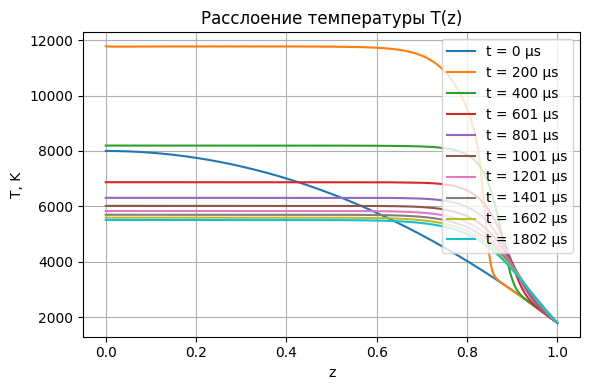

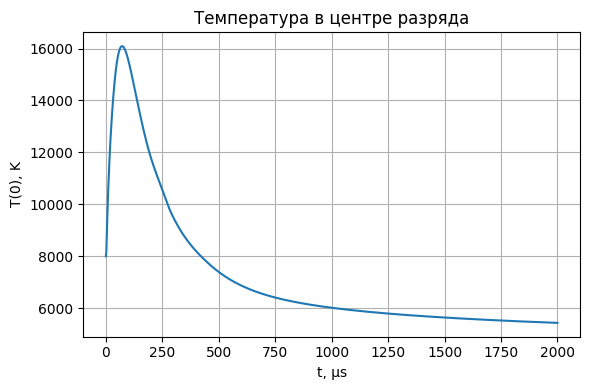

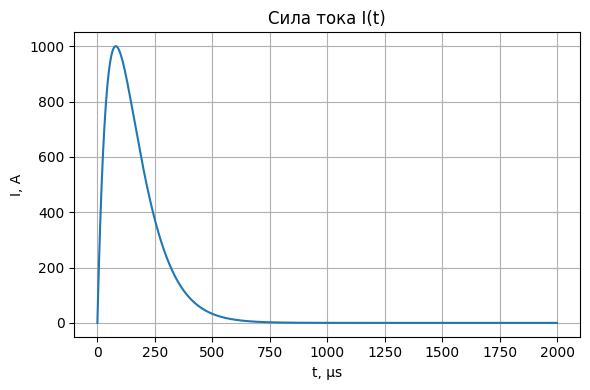

In [72]:
plt.figure(figsize=(6,4))
for i in range(0, len(time_slices), max(1, len(time_slices)//10)):
    plt.plot(z_arr, time_slices[i],
             label=f"t = {t_arr[i]*1e6:.0f} μs",
             linestyle=['-','--',':','-.'][i%4])
plt.xlabel('z')
plt.ylabel('T, K')
plt.title('Расслоение температуры T(z)')
plt.legend()
plt.grid()
plt.tight_layout()

center_T = [T[0] for T in time_slices]
plt.figure(figsize=(6,4))
plt.plot(t_arr*1e6, center_T)
plt.xlabel('t, μs')
plt.ylabel('T(0), K')
plt.title('Температура в центре разряда')
plt.grid()
plt.tight_layout()

I_vals = [calc_I(t) for t in t_arr]
plt.figure(figsize=(6,4))
plt.plot(t_arr*1e6, I_vals)
plt.xlabel('t, μs')
plt.ylabel('I, A')
plt.title('Сила тока I(t)')
plt.grid()
plt.tight_layout()

plt.show()

In [73]:
idx = np.where(abs(t_arr - 2e-4) < 1e-3)[0][0]       # индекс для t = 200 µs
print("Максимальный 'зуб' =",
      np.max(np.abs(np.diff(time_slices[idx]))), "K")

Максимальный 'зуб' = 31.03874975659801 K
